## Exploratory Data Analysis

The Kepler Mission was the first space mission dedicated to searching for earth-sized or smaller planets in the habitable zone of other stars. Kepler precisely measured the light variations of thousands of stars, looking for planetary transits. When a planet passes in front of a star, it blocks a fraction of the light coming from it. Searching for a planet thus entails looking for a drop in brightness. KOI (Kepler Object of Interest) data contains recordings of various measurements of different objects for the purpose of identifying and characterizing transiting planet candidates. 

We look at and analyse the data included in the cumulative table in this notebook.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc

# Sets up no limit for columns and rows so that we can see all columns and observe all necessary data.
pd.options.display.max_columns = None
pd.options.display.max_rows = 20

sns.set_theme()

In [32]:
df = pd.read_csv('../data/cumulative_2026.09.23_12.00.35.csv', comment='#')
df.head(10)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_disp_prov,koi_comment,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_time0,koi_time0_err1,koi_time0_err2,koi_eccen,koi_eccen_err1,koi_eccen_err2,koi_longp,koi_longp_err1,koi_longp_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_ingress,koi_ingress_err1,koi_ingress_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_ror,koi_ror_err1,koi_ror_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_prad,koi_prad_err1,koi_prad_err2,koi_sma,koi_sma_err1,koi_sma_err2,koi_incl,koi_incl_err1,koi_incl_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_dor,koi_dor_err1,koi_dor_err2,koi_limbdark_mod,koi_ldm_coeff4,koi_ldm_coeff3,koi_ldm_coeff2,koi_ldm_coeff1,koi_parm_prov,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_count,koi_num_transits,koi_tce_plnt_num,koi_tce_delivname,koi_quarters,koi_bin_oedp_sig,koi_trans_mod,koi_model_dof,koi_model_chisq,koi_datalink_dvr,koi_datalink_dvs,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_smet,koi_smet_err1,koi_smet_err2,koi_srad,koi_srad_err1,koi_srad_err2,koi_smass,koi_smass_err1,koi_smass_err2,koi_sage,koi_sage_err1,koi_sage_err2,koi_sparprov,ra,dec,koi_kepmag,koi_gmag,koi_rmag,koi_imag,koi_zmag,koi_jmag,koi_hmag,koi_kmag,koi_fwm_stat_sig,koi_fwm_sra,koi_fwm_sra_err,koi_fwm_sdec,koi_fwm_sdec_err,koi_fwm_srao,koi_fwm_srao_err,koi_fwm_sdeco,koi_fwm_sdeco_err,koi_fwm_prao,koi_fwm_prao_err,koi_fwm_pdeco,koi_fwm_pdeco_err,koi_dicco_mra,koi_dicco_mra_err,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,0,0,0,q1_q17_dr25_sup_koi,NO_COMMENT,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,2455003.539,0.002160,-0.002160,0.0,NaN,NaN,NaN,NaN,NaN,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,NaN,NaN,NaN,615.8,19.5,-19.5,0.022344,0.000832,-0.000528,3.20796,0.33173,-1.09986,LS+MCMC,2.26,0.26,-0.15,0.0853,NaN,NaN,89.66,NaN,NaN,793.0,NaN,NaN,93.59,29.45,-16.65,24.810,2.600,-2.600,Claret (2011 A&A 529 75) ATLAS LS,0.0,0.0,0.2291,0.4603,q1_q17_dr25_koi,5.135849,28.470820,35.8,2,142.0,1.0,q1_q17_dr25_tce,11111111111111111000000000000000,0.6864,Mandel and Agol (2002 ApJ 580 171),NaN,NaN,010/010797/010797460/dv/kplr010797460-20160209...,010/010797/010797460/dv/kplr010797460-001-2016...,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.14,0.15,-0.15,0.927,0.105,-0.061,0.919,0.052,-0.046,NaN,NaN,NaN,q1_q17_dr25_stellar,291.93423,48.141651,15.347,15.890,15.270,15.114,15.006,14.082,13.751,13.648,0.002,19.462294,1.400000e-05,48.141910,0.000130,0.430,0.510,0.940,0.480,-0.000200,0.000320,-0.000550,0.000310,-0.010,0.130,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,0,0,0,q1_q17_dr25_sup_koi,NO_COMMENT,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,2454995.514,0.003520,-0.003520,0.0,NaN,NaN,NaN,NaN,NaN,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,NaN,NaN,NaN,874.8,35.5,-35.5,0.027954,0.009078,-0.001347,3.02368,2.20489,-2.49638,LS+MCMC,2.83,0.32,-0.19,0.2734,NaN,NaN,89.57,NaN,NaN,443.0,NaN,NaN,9.11,2.87,-1.62,77.900,28.400,-28.400,Claret (2011 A&A 529 75) ATLAS LS,0.0,0.0,0.2291,0.4603,q1_q17_dr25_koi,7.027669,20.109507,25.8,2,25.0,2.0,q1_q17_dr25_tce,11111111111111111000000000000000,0.0023,Mandel and Agol (2002 ApJ 580 171),NaN,NaN,010/010797/010797460/dv/kplr010797460-20160209...,010/010797/010797460/dv/kplr010797460-002-2016...,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.14,0.15,-0.15,0.927,0.105,-0.061,0.919,0.052,-0.046,NaN,NaN,NaN,q1_q17_dr25_stellar,291.93423,48.141651,15.347,15.890,15.

In [33]:
del df['rowid'] # Automatically generating row IDs starting from 0 instead

In [34]:
df.shape # 9564 rows and 140 columns

(9564, 140)

### Column Information
Our dataset contains 140 columns.

Online column information: https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html

**Notable columns:**
- `koi_disposition` is the target variable, which contains the manually CONFIRMED data. `koi_pdisposition` contains the most probable explanation of the KOI provided by Kepler, with the positive status giving a CANDIDATE.

- `koi_score` indicates the confidence in the KOI disposition. For CANDIDATEs, a higher value indicates more confidence, whilst for FALSE POSITIVEs, a higher value indicates less confidence. This translates cleanly into a probability distribution, where 0 signifies a strong disagreement and 1 signifies a strong agreement. I will not include this in a model, however will compare the scores I give to candidate planets with scores obtained by Kepler.

- `koi_fpflag_<nt/ss/co/ec>` are specific binary KOI flags computed by Kepler in order to categorise a planet as a candidate or false positive, and may be a form of leakage.

- `koi_comment` includes a description on why an object has been classified as a FALSE POSITIVE, which directly relates to our target variable. Interesting to see, however important to remove from training data, to prevent data leakage.

- Columns from `koi_period` to `koi_dor`, excluding categorical column `koi_fittype`, are transit observation data, including uncertainties, important for classification. Interesting columns include `koi_duration`, which measures the duration of a transit (planet dimming a star), `koi_depth` is a fraction of stellar flux lost at the minimum of the planetary transit and `koi_period` is the interval between consecutive planetary transits. I will be removing the uncertainty columns.

- Threshold-Crossing Event (TCE) information is a sequence of transit features in the flux time series of a given observation that resembles the signature of a transiting planet sufficiently enough that the observation is passed on for further inspection. Adding all the dips together gives more information than one, and if a signal passes a threshold, the object is saved as a TCE. This includes features from `koi_max_sngle_ev` to `koi_model_chisq`, excluding categorial reference `koi_trans_mod`. `koi_count` signifies the number of planet candidates indentified in a system, which may be a form of data leakage if used for a model.

- Stellar parameters `koi_steff` to `koi_sage` hold stellar temperature, gravity, metallicity, etc. and their associated uncertanties.

- KIC (Kepler Input Catalog) parameters `ra` to `koi_kmag` (photometric and physical data for sources in the Kepler Mission field of view).

- Pixel-Based KOI Vetting Statistics: Flux-weighted centroiding measures how the center of light in the collected pixels changes during a transit and PRF-fit difference images localize the source of the transit signal. Both of these provide an estimate of the location of the source of the transit signal.


In [35]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 140 columns):
 #    Column              Non-Null Count  Dtype  
---   ------              --------------  -----  
 0    kepid               9564 non-null   int64  
 1    kepoi_name          9564 non-null   str    
 2    kepler_name         2748 non-null   str    
 3    koi_disposition     9564 non-null   str    
 4    koi_vet_stat        9564 non-null   str    
 5    koi_vet_date        9564 non-null   str    
 6    koi_pdisposition    9564 non-null   str    
 7    koi_score           8054 non-null   float64
 8    koi_fpflag_nt       9564 non-null   int64  
 9    koi_fpflag_ss       9564 non-null   int64  
 10   koi_fpflag_co       9564 non-null   int64  
 11   koi_fpflag_ec       9564 non-null   int64  
 12   koi_disp_prov       9564 non-null   str    
 13   koi_comment         8355 non-null   str    
 14   koi_period          9564 non-null   float64
 15   koi_period_err1     9110 non-null   float64
 16

In [36]:
df.koi_vet_stat.value_counts()

koi_vet_stat
Done    9564
Name: count, dtype: int64

### Target Analysis

Our target variable is koi_disposition, which takes categorical CANDIDATE, CONFIRMED and FALSE POSITIVE values. In this project, I will perform binary classification to categorize objects as either FALSE POSITIVE or CONFIRMED, and use the resulting model to produce the probability of an object being CONFIRMED, given a CANDIDATE label. 

There are 4839 false positives and 2748 confirmed planets in the dataset. This means that a model fit on this data would by default lean towards predicting a false positive. Class imbalance in this data is quite mild and plainly ignoring the confirmed candidates and predicting false positives only would score the model ~64% accuracy. If I use accuracy for my predictions, it is important to keep this number in mind.

In [37]:
df.koi_disposition.value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64

In [51]:
FP = (df['koi_disposition'] == 'FALSE POSITIVE').sum()
TOT = FP + (df['koi_disposition'] == 'CONFIRMED').sum()

round(FP/TOT, 2)

np.float64(0.64)

Looking at the histogram for the target variable and the probability that Kepler attributed to an object being either a candidate or a false positive, I observe that there are is low number of false positives with a high probability (unsure observations) and vice versa. These are important to consider, as they may be outliers. Additionally, majority of candidates are leaning towards being confirmed. I expect that the candidates will follow a similar distribution once we attribute the probabilities provided by our model, given that we are aiming to replicate the Kepler findings.

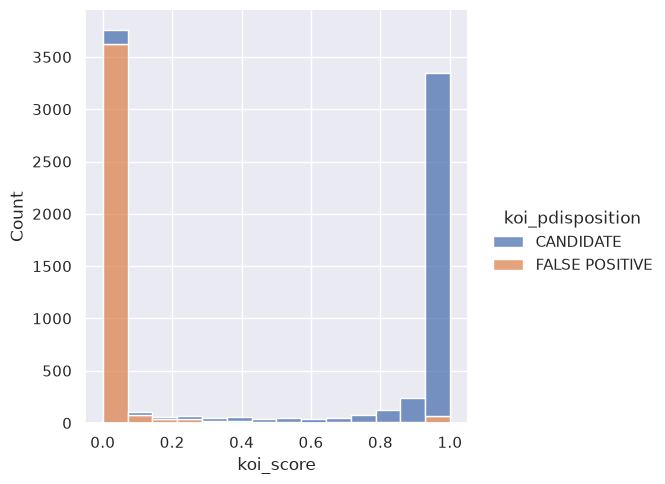

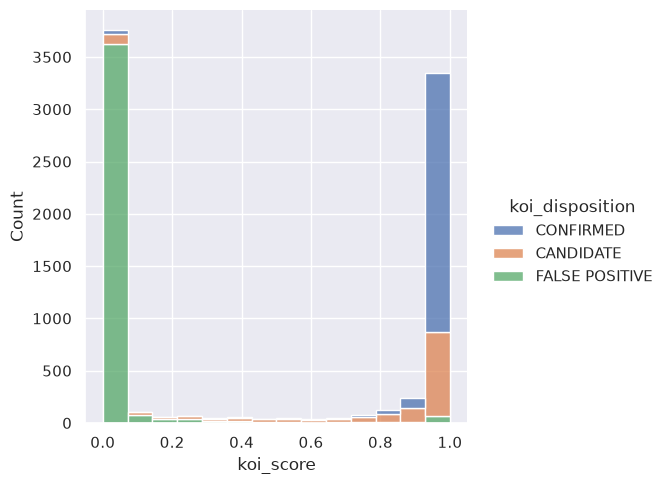

In [91]:
sns.displot(data=df, x='koi_score', hue='koi_pdisposition', multiple='stack')
sns.displot(data=df, x='koi_score', hue='koi_disposition', multiple='stack')

Next: 
- Examine columns which I marked as potential data leakage.
- Use correlation or mutual information to check each features link to target.
- Examine missing data columns and whether any of them are linked to target or random.